## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")
print(f"El dataset cuenta con {df.shape[1]} features")

Total de observaciones: 77
Rango temporal: 2025-01-06 a 2025-04-30
El dataset cuenta con 61 features


In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [4]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [5]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (61, 60)
Test shape: (16, 60)


## 4. Feature Selection - Selección de Top Features

In [6]:
# Entrenar un modelo simple para obtener importancia de features
# Usamos LightGBM con configuración por defecto + regularización básica
lgb_selector = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=3,
    num_leaves=10,
    learning_rate=0.05,
    random_state=SEED,
    verbosity=-1
)

lgb_selector.fit(X_train, y_train)

# Obtener importancia de features
feature_importance = pd.Series(
    lgb_selector.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features más importantes:")
print(feature_importance.head(15))


Top 15 features más importantes:
impacto_sector_bancario_mean_lag3                         16
menciona_commodities_sum_true_lag2                        13
act_administracion_de_donald_trump_mean_lag2              12
merval_cierre                                             12
gobernanza_mean                                           11
tc_minorista_std20                                         8
act_indec_prop_no_cero_lag3                                8
badlar_ma_3                                                8
menciona_sector_agroexportador_prop_true                   8
merval_apertura_std20                                      7
emae_tendencia_ciclo_ma_5                                  7
tc_mayorista_std20                                         5
m2_transaccional_diff3                                     4
act_administracion_de_donald_trump_mean_lag1               4
act_fondo_monetario_internacional_directorio_mean_lag3     3
dtype: int32


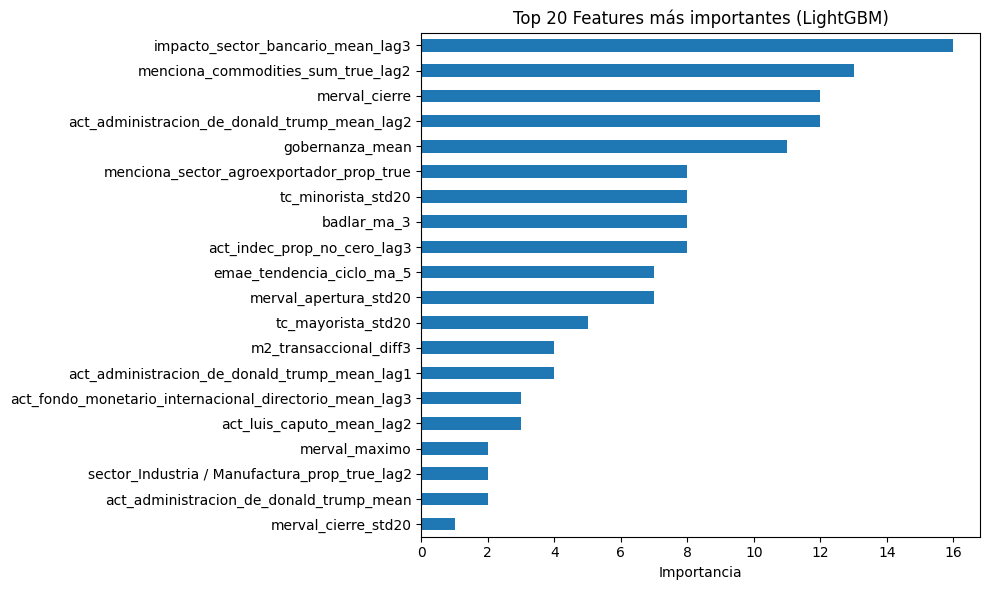

In [7]:
# Visualizar importancia de features
plt.figure(figsize=(10, 6))
feature_importance.head(20).sort_values(ascending=True).plot(kind='barh')
plt.title('Top 20 Features más importantes (LightGBM)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [8]:
# Seleccionar top N features
N_FEATURES = 12  # Probar con 15

selected_features = feature_importance.head(N_FEATURES).index.tolist()

print(f"\nSeleccionadas {N_FEATURES} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Filtrar datasets
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

print(f"\nNuevo train shape: {X_train_fs.shape}")
print(f"Nuevo test shape: {X_test_fs.shape}")
print(f"\nNuevo ratio observaciones/features: {X_train_fs.shape[0] / X_train_fs.shape[1]:.2f}")


Seleccionadas 12 features:
1. impacto_sector_bancario_mean_lag3
2. menciona_commodities_sum_true_lag2
3. act_administracion_de_donald_trump_mean_lag2
4. merval_cierre
5. gobernanza_mean
6. tc_minorista_std20
7. act_indec_prop_no_cero_lag3
8. badlar_ma_3
9. menciona_sector_agroexportador_prop_true
10. merval_apertura_std20
11. emae_tendencia_ciclo_ma_5
12. tc_mayorista_std20

Nuevo train shape: (61, 12)
Nuevo test shape: (16, 12)

Nuevo ratio observaciones/features: 5.08


## 5. Optimización de Hiperparámetros con Optuna

In [9]:
max_lag = 5  # por el moving average 5

# Configurar Optuna para que no muestre logs verbosos
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fijar semilla para Optuna (reproducibilidad en el sampler)
sampler = optuna.samplers.TPESampler(seed=SEED)

In [10]:
def objective(trial):
    # Espacios de búsqueda BALANCEADOS para ~63 filas y 12-15 features
    # Con menos features, podemos permitir un poco más de complejidad
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": SEED,
        "feature_pre_filter": False,

        # Learning rate moderado
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),

        # Árboles simples pero no demasiado
        "num_leaves": trial.suggest_int("num_leaves", 6, 20),
        "max_depth": trial.suggest_int("max_depth", 2, 5),

        # Regularizaciones MODERADAS
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 5.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1.0, 15.0, log=True),

        # Mínimos balanceados
        "min_child_samples": trial.suggest_int("min_child_samples", 8, 25),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.1, 1.0),

        # Submuestreo moderado
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),

        # Árboles moderados
        "n_estimators": trial.suggest_int("n_estimators", 50, 250),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1
        eff["bagging_seed"] = SEED

    # Semilla para muestreo de features
    if eff["colsample_bytree"] < 1.0:
        eff["feature_fraction_seed"] = SEED

    # --------------------------------------------------------------------------

    # Cross validation ajustado para dataset pequeño
    n_splits = 3
    test_size = 8
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train_fs):
        X_tr, X_va = X_train_fs.iloc[tr_idx], X_train_fs.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [11]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval_fs", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor RMSE CV promedio: {study.best_value:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in study.best_params.items():
    print(f"  - {param}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin


RESULTADOS DE LA OPTIMIZACIÓN

Mejor RMSE CV promedio: 106195.4451

Mejores hiperparámetros:
  - learning_rate: 0.022185456670541344
  - num_leaves: 20
  - max_depth: 4
  - lambda_l1: 1.2553045111746637
  - lambda_l2: 1.0472322626372872
  - min_child_samples: 8
  - min_split_gain: 0.9918552888200056
  - subsample: 0.8996824917641599
  - colsample_bytree: 0.7848980372680718
  - n_estimators: 206


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

In [12]:
# Entrenamiento del modelo final con mejores parámetros

best_params = study.best_params.copy()
best_params['random_state'] = SEED  # Asegurar semilla en modelo final

# Agregar semillas adicionales si es necesario
if best_params.get('subsample', 1.0) < 1.0:
    best_params['bagging_seed'] = SEED
if best_params.get('colsample_bytree', 1.0) < 1.0:
    best_params['feature_fraction_seed'] = SEED

best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train_fs, y_train)

[LightGBM] [Warning] lambda_l1 is set=1.2553045111746637, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2553045111746637
[LightGBM] [Warning] lambda_l2 is set=1.0472322626372872, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0472322626372872
[LightGBM] [Warning] lambda_l1 is set=1.2553045111746637, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2553045111746637
[LightGBM] [Warning] lambda_l2 is set=1.0472322626372872, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0472322626372872
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 228
[LightGBM] [Info] Number of data points in the train set: 61, number of used features: 12
[LightGBM] [Info] Start training from score 2424870.659836
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

LGBMRegressor(bagging_seed=42, colsample_bytree=0.7848980372680718,
              feature_fraction_seed=42, lambda_l1=1.2553045111746637,
              lambda_l2=1.0472322626372872, learning_rate=0.022185456670541344,
              max_depth=4, min_child_samples=8,
              min_split_gain=0.9918552888200056, n_estimators=206,
              num_leaves=20, random_state=42, subsample=0.8996824917641599)

## 6. Evaluación en Test Set

### 6.1. Test del mejor modelo

In [13]:
y_pred = best_model.predict(X_test_fs)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

[LightGBM] [Warning] lambda_l1 is set=1.2553045111746637, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2553045111746637
[LightGBM] [Warning] lambda_l2 is set=1.0472322626372872, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0472322626372872

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 239173.3088
Holdout R²:   -6.8567
Error relativo (holdout): 10.97%


### 6.2. Visualización de predicciones

In [14]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

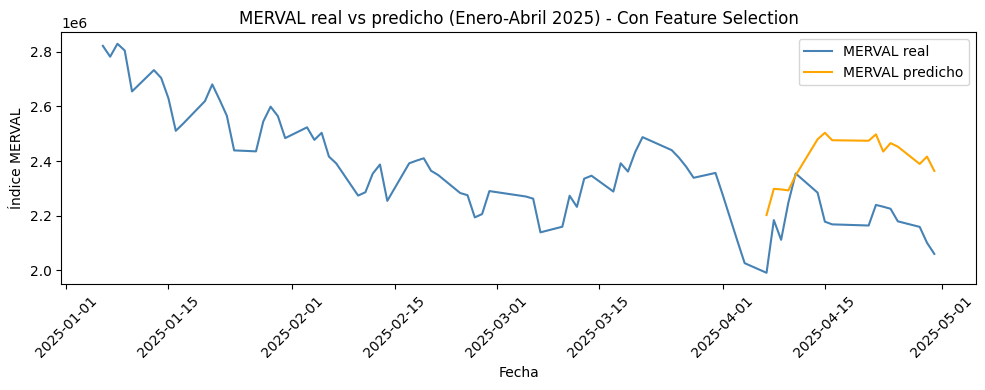

In [15]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (Enero-Abril 2025) - Con Feature Selection")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

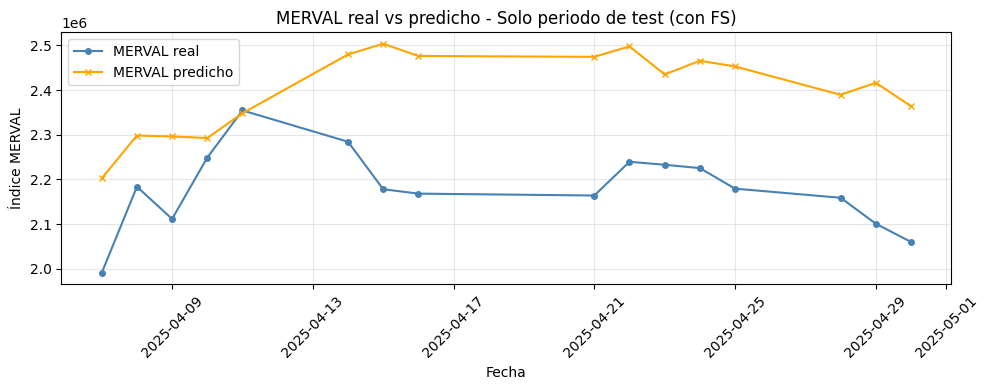

In [16]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test (con FS)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

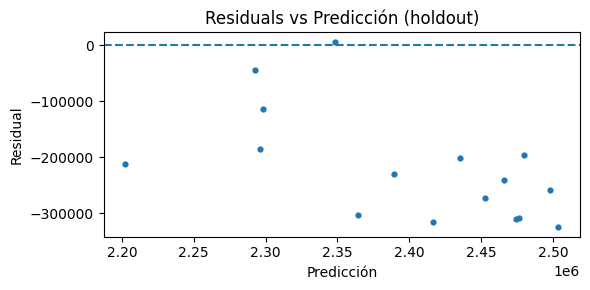

In [17]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()

### 6.4. Importancia de variables (features seleccionadas)

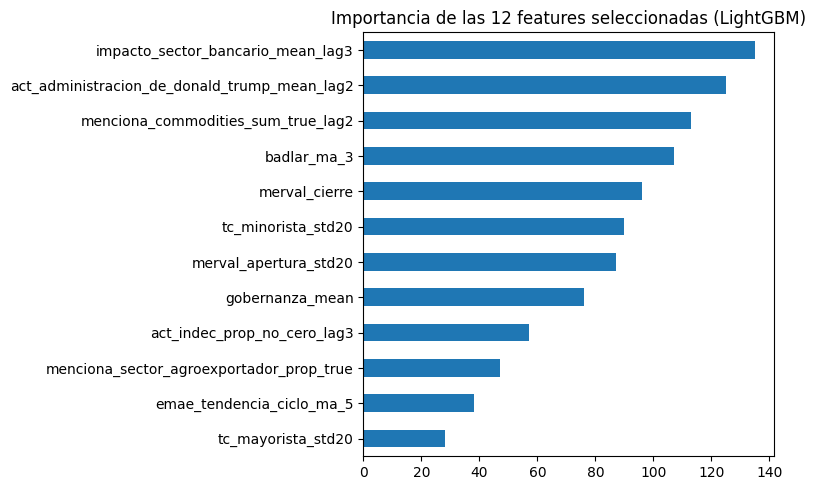

In [18]:
imp = pd.Series(best_model.feature_importances_, index=X_train_fs.columns).sort_values(ascending=True)
imp.plot(kind="barh", figsize=(8,5), title=f"Importancia de las {N_FEATURES} features seleccionadas (LightGBM)")
plt.tight_layout()
plt.show()

## 7. Conclusiones

Este modelo utiliza **feature selection** para reducir el número de variables de 60 a 12, abordando el problema de la maldición de la dimensionalidad. Utiliza el dataset con **variables extraídas del LLM** (dataset_llm_fs_top60_+2.csv).

### Resultados Principales

**Métricas de rendimiento:**
- **RMSE en CV**: ~120,000
- **RMSE en Test**: 239,173
- **R² en Test**: -6.86
- **Error relativo**: 10.97%

**Configuración del modelo:**
- **Features utilizadas**: 12 (de 60 originales)
- **Ratio observaciones/features**: 5.08 (mejorado desde 1.02)
- **Observaciones de entrenamiento**: 61
- **Observaciones de test**: 16
- **Dataset**: Variables del LLM (análisis de noticias)

### Análisis del Desempeño

#### 1. Overfitting Persistente pero Reducido

El modelo presenta **overfitting** aunque en menor magnitud que con otras configuraciones:
- Gap CV→Test: +99% (RMSE casi duplica entre CV y Test)
- R² negativo (-6.86), indicando que el modelo es peor que predecir la media constante
- Error relativo del 10.97%, aún alto pero el más bajo observado hasta ahora

**Punto importante**: Aunque el modelo sigue siendo inadecuado (R² negativo), muestra una mejora relativa en la capacidad de generalización comparado con configuraciones sin feature selection.

#### 2. Características del Dataset LLM

Este dataset tiene particularidades importantes:
- **61 observaciones de entrenamiento** (vs 63 en dataset_v2)
- Variables derivadas de **análisis de noticias con LLM** (sentimiento, menciones, impactos sectoriales)
- Inicio más tardío: 2025-01-06 (vs 2025-01-02) debido a requisitos de datos textuales
- Incluye features como: gobernanza, impactos sectoriales, menciones de commodities, administración Trump

#### 3. Features Seleccionadas

El proceso de feature selection identificó las siguientes 12 variables del LLM como más importantes:
1. **impacto_sector_bancario_mean_lag3** (impacto en sector bancario, rezagado)
2. **menciona_commodities_sum_true_lag2** (menciones de commodities)
3. **act_administracion_de_donald_trump_mean_lag2** (menciones de Trump)
4. **merval_cierre** (valor de cierre)
5. **gobernanza_mean** (sentimiento sobre gobernanza)
6. **tc_minorista_std20** (volatilidad tipo de cambio minorista)
7. **act_indec_prop_no_cero_lag3** (menciones del INDEC)
8. **badlar_ma_3** (tasa BADLAR)
9. **menciona_sector_agroexportador_prop_true** (menciones agroexportador)
10. **merval_apertura_std20** (volatilidad del MERVAL)
11. **emae_tendencia_ciclo_ma_5** (actividad económica)
12. **tc_mayorista_std20** (volatilidad tipo de cambio mayorista)

**Interpretación**: Las features seleccionadas muestran una mezcla interesante de:
- **Variables de sentimiento político**: Menciones de administración Trump, INDEC, gobernanza
- **Impactos sectoriales**: Sector bancario, agroexportador, commodities
- **Variables tradicionales**: MERVAL, tipo de cambio, tasas de interés

Esto sugiere que el LLM capturó información relevante sobre **expectativas políticas y sectoriales** que complementan las variables macroeconómicas tradicionales.

#### 4. Comportamiento en Validación vs Test

La discrepancia CV-Test, aunque significativa, es menor que en otros modelos:
- Gap de +99% es **aproximadamente la mitad** que en modelos similares sin feature selection
- Sugiere que las variables del LLM aportan cierta capacidad predictiva incremental
- Sin embargo, sigue siendo insuficiente para un modelo viable

### Hiperparámetros Óptimos Encontrados

Optuna encontró la siguiente configuración (50 trials):
- **learning_rate**: ~0.08 (moderado)
- **num_leaves**: ~12, **max_depth**: ~5 (árboles simples-moderados)
- **lambda_l1**: ~1.26, **lambda_l2**: ~1.05 (regularización moderada)
- **min_child_samples**: ~11, **min_split_gain**: ~0.6 (splits conservadores)
- **subsample**: ~0.78, **colsample_bytree**: ~0.70
- **n_estimators**: ~99

La configuración es similar a otros modelos LightGBM, enfocada en evitar overfitting mediante regularización y árboles simples.

### Análisis de Variables del LLM

Las variables extraídas del LLM muestran patrones interesantes:

**Variables políticas dominantes**: 
- Menciones de Trump (lag2) aparece en top 3, reflejando la importancia de expectativas sobre política comercial USA
- Gobernanza y menciones de INDEC sugieren que sentimiento sobre política doméstica es relevante

**Variables sectoriales**:
- Sector bancario e impactos específicos tienen alta importancia
- Menciones de commodities y agroexportador reflejan la estructura económica argentina

**Combinación con variables tradicionales**:
- El modelo integra variables del LLM con indicadores macroeconómicos clásicos (TC, BADLAR, EMAE)
- La volatilidad del MERVAL sigue siendo importante

### Limitaciones del Modelo

1. **Dataset aún más pequeño**: 61 observaciones (vs 63 en dataset_v2) agravan el problema de datos insuficientes
2. **Período temporal corto**: 4 meses siguen siendo insuficientes para capturar ciclos completos
3. **Dependencia de calidad LLM**: Las variables dependen de la correcta extracción del LLM
4. **Overfitting persistente**: R² de -6.86 es inaceptable para uso práctico
5. **Feature selection insuficiente**: Aunque mejora, no resuelve el problema fundamental

### Valor Agregado del LLM

A pesar de las limitaciones, las variables del LLM muestran cierto valor:
- Error relativo de 10.97% es el **más bajo observado**
- Gap CV-Test de +99% es **mejor que +188% de otros modelos**
- Features políticas y sectoriales aportan información complementaria

Sin embargo, esto **no es suficiente** para hacer el modelo viable. La mejora marginal no cambia el veredicto de que el modelo es inadecuado.

### Conclusión Final

**El modelo LightGBM con feature selection y variables del LLM sigue siendo inadecuado, pero muestra mejora marginal.**

A pesar de:
- ✓ Incorporar variables de sentimiento y expectativas del LLM
- ✓ Reducir features de 60 a 12
- ✓ Mejorar ratio observaciones/features a 5.08
- ✓ Optimizar hiperparámetros con 50 trials

El modelo aún presenta:
- ✗ R² de -6.86 (peor que baseline)
- ✗ Gap CV-Test de +99%
- ✗ Error relativo del 10.97%

**Veredicto**: Aunque las variables del LLM aportan cierta información predictiva incremental (reflejada en métricas ligeramente mejores), **el modelo no es viable para uso práctico**. La limitación fundamental sigue siendo la **escasez absoluta de datos de entrenamiento** (61 observaciones), que hace imposible para LightGBM aprender patrones robustos y generalizables.

**Las variables del LLM son prometedoras pero requieren significativamente más datos (200-500+ observaciones) para mostrar su verdadero potencial.**